<a href="https://colab.research.google.com/github/wvb20/cv-face-alignment/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
This Colab worksheet provides a starting point for the coursework assignment for 996G5A: Computer Vision.

# Data Loading

In [12]:
# Exploratory Data Analysis
# Download the data stored in a zipped numpy array
# If you're running all your experiments on a machine at home rather than using colab, then make sure you save it rather than repeatedly downloading it.

# training images
#!wget "https://sussex.box.com/shared/static/0jrzqz9cc5898x5d1az8zbqq5wr1abrm.npz" -O face_alignment_training_images.npz
# test images (without points)
#!wget "https://sussex.box.com/shared/static/vvp53svnpsp12g6wsrjipc4zkhfrtgp3.npz" -O face_alignment_test_images.npz

In [13]:
# Data/workspace paths — local or Colab ===
# === Bootstrap — local or Colab ===

import os, subprocess, sys
from pathlib import Path

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_PATH = '/content/cv-face-alignment'
    if not os.path.exists(REPO_PATH):
        subprocess.run(
            ['git', 'clone', 'https://github.com/wvb20/cv-face-alignment.git', REPO_PATH],
            check=True,
        )
    else:
        subprocess.run(['git', '-C', REPO_PATH, 'pull'], check=True)
else:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'config.py').exists():
            REPO_PATH = str(candidate)
            break
    else:
        raise RuntimeError(
            'Could not find the repo root. Start Jupyter from the repository or set CV_FACE_ALIGNMENT_REPO_ROOT.'
        )

if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

try:
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except Exception:
    pass

from src.runtime import configure_notebook_runtime
runtime = configure_notebook_runtime(REPO_PATH)
from src import config

DRIVE_PROJECT_DIR = config.DRIVE_PROJECT_DIR
DATA_DIR = config.DATA_DIR
FIGURES_DIR = config.FIGURES_DIR

runtime_label = 'Colab' if runtime.in_colab else 'Local'

print(f'Runtime:   {runtime_label}')
print(f'✓ Data:    {DATA_DIR}')
print(f'✓ Figures: {FIGURES_DIR}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Runtime:   Local
✓ Data:    /Users/willvaughn/Developer/cv-face-alignment/data
✓ Figures: /Users/willvaughn/Developer/cv-face-alignment/figures


# Load the data

In [14]:
import numpy as np
import matplotlib.pyplot as plt

train_path = f'{DATA_DIR}/face_alignment_training_images.npz'
test_path  = f'{DATA_DIR}/face_alignment_test_images.npz'

# Load the training data using np.load
data_train = np.load(train_path, allow_pickle=True)
# Extract the images
images_train = data_train['images']
# and the data points
pts_train = data_train['points']
print(images_train.shape, pts_train.shape)

# same for test data (without labels)
data_test = np.load(test_path, allow_pickle=True)
images_test = data_test['images']
print(images_test.shape)

(2811, 256, 256, 3) (2811, 5, 2)
(554, 256, 256, 3)


# Data Visualisation
Here's an example of how to display the images and their points

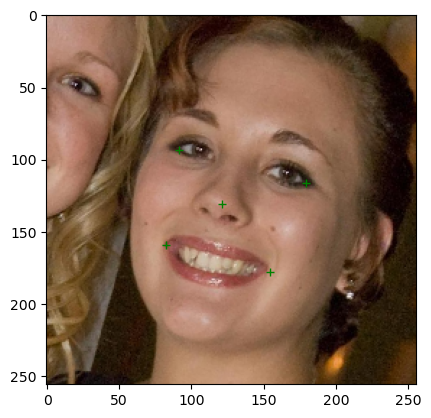

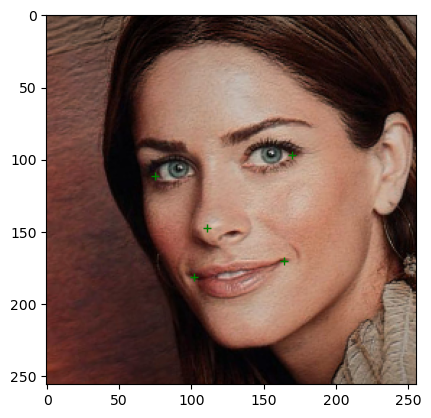

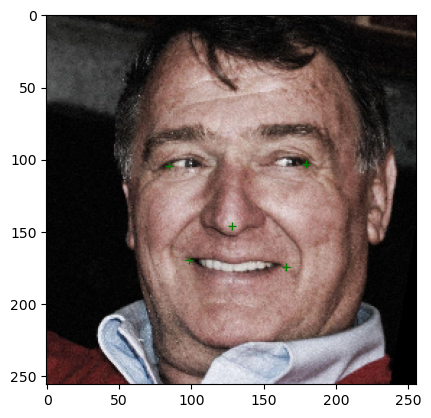

In [15]:
# Sample visualisation from the original assignment. 

def visualise_pts(img, pts):
  import matplotlib.pyplot as plt
  plt.imshow(img)
  plt.plot(pts[:, 0], pts[:, 1], '+g')
  plt.show()

for i in range(3):
  idx = np.random.randint(0, images_train.shape[0])
  visualise_pts(images_train[idx, ...], pts_train[idx, ...])

# Calculating Prediction Error and exporting results

In [16]:
# Prediction error code from the original assignment.

def euclid_dist(pred_pts, gt_pts):
  """
  Calculate the euclidean distance between pairs of points
  :param pred_pts: The predicted points
  :param gt_pts: The ground truth points
  :return: An array of shape (no_points,) containing the distance of each predicted point from the ground truth
  """
  import numpy as np
  pred_pts = np.reshape(pred_pts, (-1, 2))
  gt_pts = np.reshape(gt_pts, (-1, 2))
  return np.sqrt(np.sum(np.square(pred_pts - gt_pts), axis=-1))


In [17]:
def save_as_csv(points, location = '.'):
    """
    Save the points out as a .csv file
    :param points: numpy array of shape (no_test_images, no_points, 2) to be saved
    :param location: Directory to save results.csv in. Default to current working directory
    """
    assert points.shape[0]==554, 'wrong number of image points, should be 554 test images'
    assert np.prod(points.shape[1:])==5*2, 'wrong number of points provided. There should be 5 points with 2 values (x,y) per point'
    np.savetxt(location + '/results_task2.csv', np.reshape(points, (points.shape[0], -1)), delimiter=',')


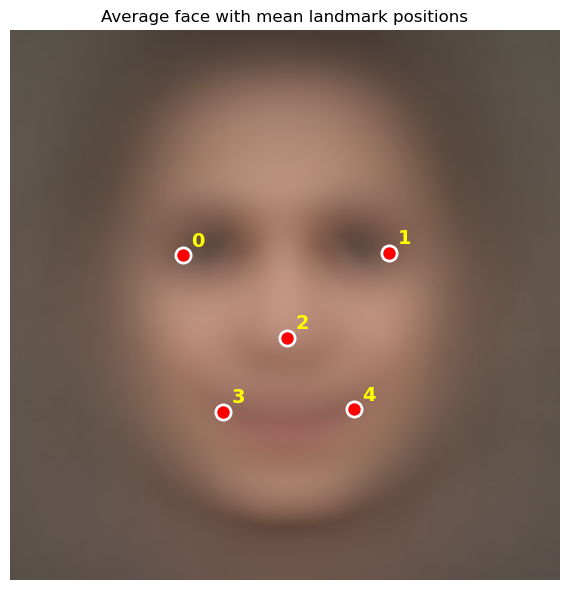

Mean landmark positions (x, y):
  Index 0: (  79.9,  104.3)
  Index 1: ( 176.1,  103.1)
  Index 2: ( 128.7,  142.6)
  Index 3: (  98.7,  177.1)
  Index 4: ( 159.7,  176.1)


In [18]:
# === Average face — overlay mean landmarks on mean image ===
# Average each of the provided landmarks in the training data
# Average all of the images together into a blended single image
# Plot the average landmark points on the average face image

mean_image  = images_train.mean(axis=0).astype(np.uint8)
mean_points = pts_train.mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(mean_image)
ax.scatter(mean_points[:, 0], mean_points[:, 1], s=120, c='red',
           edgecolors='white', linewidths=2, zorder=3)
for i, (x, y) in enumerate(mean_points):
    ax.annotate(str(i), (x, y), color='yellow', fontsize=14,
                fontweight='bold',
                xytext=(6, 6), textcoords='offset points')
ax.set_title('Average face with mean landmark positions')
ax.axis('off')

fig.tight_layout()
plt.savefig(f'{FIGURES_DIR}/02_average_face.png', dpi=120, bbox_inches='tight')
plt.show()

print('Mean landmark positions (x, y):')
for i, (x, y) in enumerate(mean_points):
    print(f'  Index {i}: ({x:6.1f}, {y:6.1f})')

In [19]:
# === Create reproducible train/val split (run once, then load) ===
SPLIT_PATH = f'{DRIVE_PROJECT_DIR}/data/train_val_split.npz'

if os.path.exists(SPLIT_PATH):
    split = np.load(SPLIT_PATH)
    train_idx, val_idx = split['train_idx'], split['val_idx']
    print(f'Loaded existing split: {len(train_idx)} train, {len(val_idx)} val')
else:
    rng = np.random.default_rng(seed=42)
    n = len(images_train)
    perm = rng.permutation(n)
    n_val = int(0.15 * n)
    val_idx, train_idx = perm[:n_val], perm[n_val:]
    np.savez(SPLIT_PATH, train_idx=train_idx, val_idx=val_idx)
    print(f'Created split: {len(train_idx)} train, {len(val_idx)} val')
    print(f'Saved to {SPLIT_PATH}')

Loaded existing split: 2390 train, 421 val


In [20]:
# === Coordinate range and image intensity stats ===
# Sanity check coordinates, collect information on image intensities.
print('LANDMARK COORDINATES')
print(f'  X range: [{pts_train[..., 0].min():.1f}, {pts_train[..., 0].max():.1f}]')
print(f'  Y range: [{pts_train[..., 1].min():.1f}, {pts_train[..., 1].max():.1f}]')
print(f'  All within image bounds (0-256)?  '
      f'{(pts_train.min() >= 0) and (pts_train.max() <= 256)}')

# Inter-ocular distances (will be used as NME normaliser)
iod = np.linalg.norm(pts_train[:, 1] - pts_train[:, 0], axis=1)
print(f'\nINTER-OCULAR DISTANCE (pixels)')
print(f'  mean={iod.mean():.1f}, std={iod.std():.1f}, '
      f'min={iod.min():.1f}, max={iod.max():.1f}')

print('\nIMAGE INTENSITIES (per channel mean/std, normalised to [0,1])')
imgs_norm = images_train.astype(np.float32) / 255.0
for c, name in enumerate(['R', 'G', 'B']):
    print(f'  {name}: mean={imgs_norm[..., c].mean():.3f}, '
          f'std={imgs_norm[..., c].std():.3f}')

LANDMARK COORDINATES
  X range: [48.9, 207.8]
  Y range: [62.8, 210.7]
  All within image bounds (0-256)?  True

INTER-OCULAR DISTANCE (pixels)
  mean=98.0, std=12.1, min=58.9, max=161.3

IMAGE INTENSITIES (per channel mean/std, normalised to [0,1])
  R: mean=0.469, std=0.305
  G: mean=0.374, std=0.268
  B: mean=0.325, std=0.261


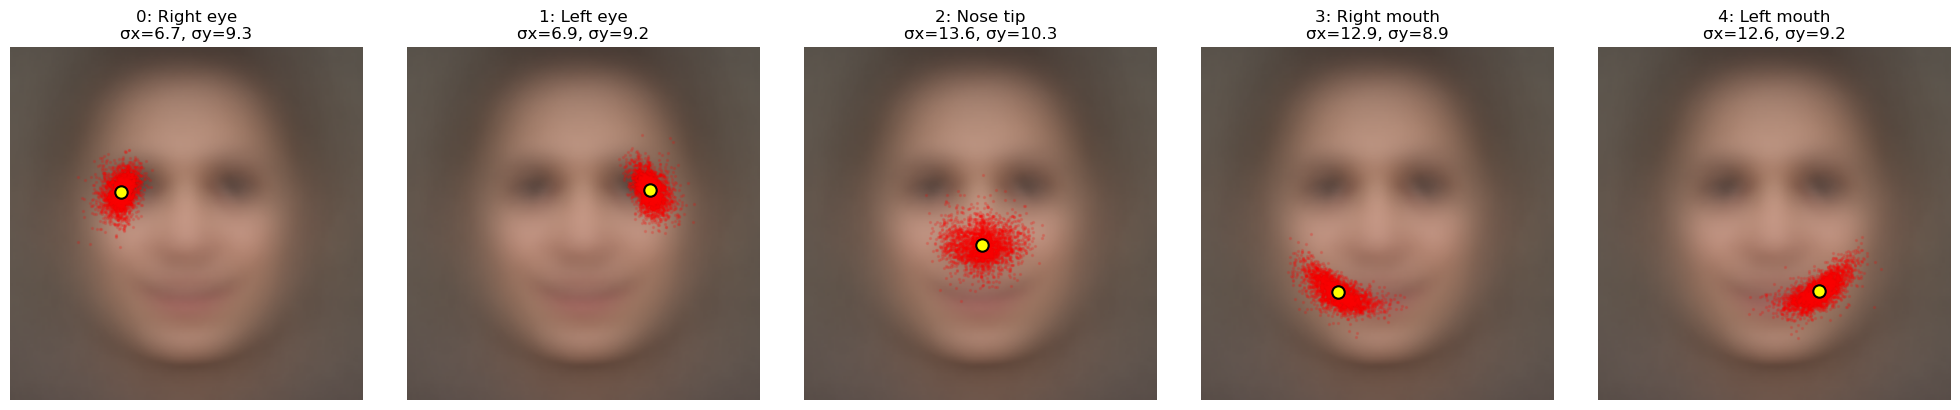

In [21]:
# === Per-landmark spatial variability ===
# Show the range of values across each landmark against the average image.
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
landmark_names = ['Right eye', 'Left eye', 'Nose tip',
                  'Right mouth', 'Left mouth']

for i, (ax, name) in enumerate(zip(axes, landmark_names)):
    ax.imshow(mean_image)
    # Plot all training landmark i positions as a scatter
    ax.scatter(pts_train[:, i, 0], pts_train[:, i, 1],
               s=2, alpha=0.15, c='red')
    # Overlay the mean
    ax.scatter(mean_points[i, 0], mean_points[i, 1],
               s=80, c='yellow', edgecolors='black', linewidths=1.5)
    std_x = pts_train[:, i, 0].std()
    std_y = pts_train[:, i, 1].std()
    ax.set_title(f'{i}: {name}\nσx={std_x:.1f}, σy={std_y:.1f}')
    ax.axis('off')

fig.tight_layout()
plt.savefig(f'{FIGURES_DIR}/03_landmark_variability.png',
            dpi=120, bbox_inches='tight')
plt.show()